# Q-Learning으로 블랙잭 문제 해결하기

![nn](./env.jpg)

Gymnasium(구 OpenAI Gym)의 `blackjack-v1` 환경을 이용하여 블랙잭 문제를 풀어봅시다.

블랙잭은 카지노에서 인기가 많은 보드게임입니다. 강원랜드에서도 블랙잭을 플레이할 수 있고, 슬롯이나 바카라보다는 플레이 가능한 공간이 적다고는 하지만 인기는 많다고 해요. 사실 슬롯과 바카라에 비하면 승률이 50%에 가장 가까운 게임이지만(47~49%) 우리나라는 바카라가 인기가 더 많다고 합니다.

목표 : 블랙잭 게임 1판을 승리하기 위해서는 가지고 있는 `카드 패의 합이 21이하` 이면서 `딜러의 패보다 높아야` 합니다.

액션 : 에이전트가 취할 수 있는 액션은 2가지가 있습니다.
- stand(stay, 0) : 플레이어가 더 이상 카드를 가져가지 않습니다.
- hit(1) : 플레이어가 카드를 가져가는데, 합이 21을 초과하면 게임을 패배하는 burst 상태가 됩니다.

접근 : Q-learning(model-free RL algo)을 통해서 블랙잭 문제를 해결해보죠.

## Import 와 환경 설정

In [38]:
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from tqdm import tqdm

import gymnasium as gym


# 블랙잭 환경 생성

env = gym.make("Blackjack-v1", sab=True) 

## 환경 관찰

`env.reset()` 으로 첫 에피소드를 시작합니다. `done = False` 으로 done 변수를 초기화 할건데 이 변수를 true로 변경하면 에피소드가 끝났는지 여부를 확인할 수 있습니다.

In [39]:
done = False
observation, info = env.reset()

# observation 튜플의 첫 번째 ele = 플레이어 카드의 합계
# observation 튜플의 두 번째 ele = 관찰 가능한 딜러의 카드
# observation 튜플의 세 번째 ele = 플레이어가 Ace 카드를 가지고 있는지 여부

# observation = (16, 9, False)

## 액션 실행

`env.step(action)`으로 환경과 상호작용 해봅시다.

step을 취하면 또 튜플을 돌려줄건데, 튜플의 원소 정보는 다음과 같아요.

- `next_state` : 에이전트가 액션을 취한뒤의 다음 State (S_t+1)
- `reward` : 에이전트가 액션을 취한뒤 받은 보상
- `terminated` : 환경이 종료됨을 나타낸 boolean // **이게 true면 새로운 episode를 시작해야해요.**
- `truncated` : 역시나 에피소드의 종료를 나타내는 boolean인데, 조기 종료 여부를 나타냅니다.
- `info` : 환경에 대한 추가적인 정보를 제공하는 딕셔너리 (무시해도 됨)

`env.render()`로 환경을 시각화할 수 있는데 traning 중에 시각화 라이브러릴 호출하면 training 성능이 저하되니 이 점은 유의하세요. training이 끝나고 추가적인 시각화 loop를 만드는 것을 추천해요.

In [40]:
action = env.action_space.sample() # 0, 1

observation, reward, terminated, truncated, info = env.step(action)
# observation=(24, 10, False)
# reward=-1.0
# terminated=True
# truncated=False
# info={}

In [42]:
class BlackjackAgent:
    def __init__(
        self,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        """
        강화학습 에이전트를 초기화합니다.
        처음에는 아무것도 없는 state-action values(q_values) 딕셔너리를 가지게 됩니다.

        Args:
            learning_rate: The learning rate
            initial_epsilon: The initial epsilon value
            epsilon_decay: The decay for epsilon
            final_epsilon: The final epsilon value
            discount_factor: The discount factor for computing the Q-value    
        """
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.training_error = []

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """
        확률에 의거하여 최고의 action을 반환합니다. (1 - epsilon)
        엡실론 수치 이하면 탐험을 진행합니다.(랜덤선택)
        그렇지 않으면 탐욕적 선택을 진행합니다.
        """

        if np.random.random() < self.epsilon:
            return env.action_space.sample()
        
        else:
            return int(np.argmax(self.q_values[obs]))
        
    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Updates the Q-value of an action."""
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        temporal_difference = (
            reward + self.discount_factor * future_q_value - self.q_values[obs][action]
        )

        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - epsilon_decay)

### 이제 훈련을 해보아요. ^^

In [43]:
# hyperparameters
learning_rate = 0.01
n_episodes = 300_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

agent = BlackjackAgent(
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)


env = gym.wrappers.RecordEpisodeStatistics(env, deque_size=n_episodes)
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    # play one episode
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # update the agent
        agent.update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()

100%|██████████| 300000/300000 [00:46<00:00, 6463.58it/s]


## Training 시각화

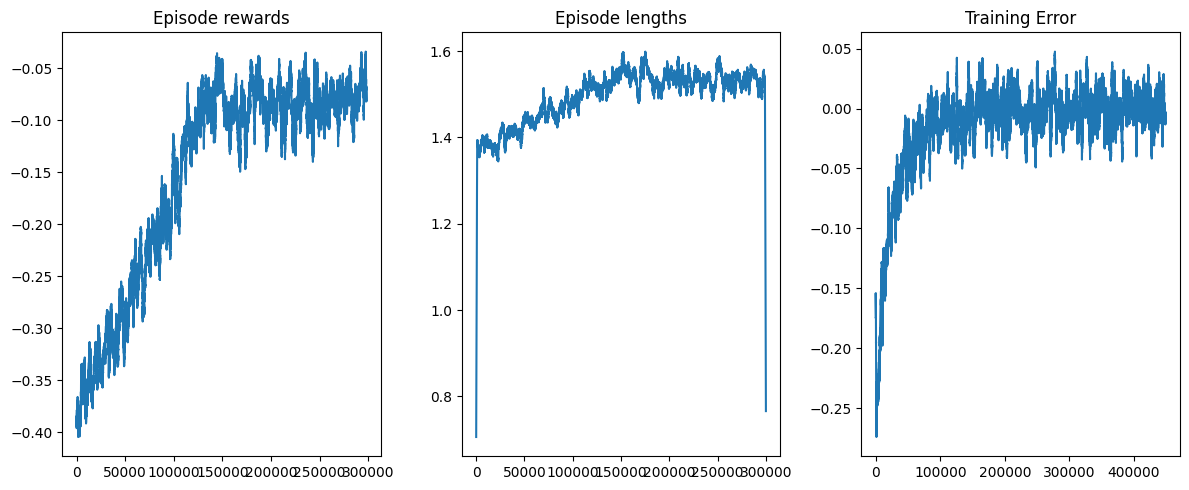

In [44]:
rolling_length = 2000
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))
axs[0].set_title("Episode rewards")
# compute and assign a rolling average of the data to provide a smoother graph
reward_moving_average = (
    np.convolve(
        np.array(env.return_queue).flatten(), np.ones(rolling_length), mode="valid"
    )
    / rolling_length
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[1].set_title("Episode lengths")
length_moving_average = (
    np.convolve(
        np.array(env.length_queue).flatten(), np.ones(rolling_length), mode="same"
    )
    / rolling_length
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[2].set_title("Training Error")
training_error_moving_average = (
    np.convolve(np.array(agent.training_error), np.ones(rolling_length), mode="same")
    / rolling_length
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
plt.tight_layout()
plt.show()

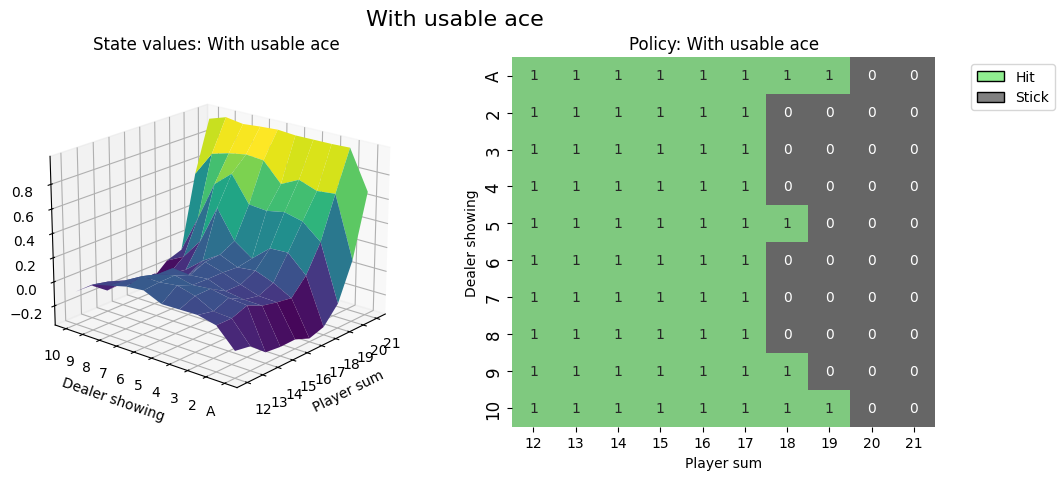

In [45]:
def create_grids(agent, usable_ace=False):
    """Create value and policy grid given an agent."""
    # convert our state-action values to state values
    # and build a policy dictionary that maps observations to actions
    state_value = defaultdict(float)
    policy = defaultdict(int)
    for obs, action_values in agent.q_values.items():
        state_value[obs] = float(np.max(action_values))
        policy[obs] = int(np.argmax(action_values))

    player_count, dealer_count = np.meshgrid(
        # players count, dealers face-up card
        np.arange(12, 22),
        np.arange(1, 11),
    )

    # create the value grid for plotting
    value = np.apply_along_axis(
        lambda obs: state_value[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    value_grid = player_count, dealer_count, value

    # create the policy grid for plotting
    policy_grid = np.apply_along_axis(
        lambda obs: policy[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    return value_grid, policy_grid


def create_plots(value_grid, policy_grid, title: str):
    """Creates a plot using a value and policy grid."""
    # create a new figure with 2 subplots (left: state values, right: policy)
    player_count, dealer_count, value = value_grid
    fig = plt.figure(figsize=plt.figaspect(0.4))
    fig.suptitle(title, fontsize=16)

    # plot the state values
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(
        player_count,
        dealer_count,
        value,
        rstride=1,
        cstride=1,
        cmap="viridis",
        edgecolor="none",
    )
    plt.xticks(range(12, 22), range(12, 22))
    plt.yticks(range(1, 11), ["A"] + list(range(2, 11)))
    ax1.set_title(f"State values: {title}")
    ax1.set_xlabel("Player sum")
    ax1.set_ylabel("Dealer showing")
    ax1.zaxis.set_rotate_label(False)
    ax1.set_zlabel("Value", fontsize=14, rotation=90)
    ax1.view_init(20, 220)

    # plot the policy
    fig.add_subplot(1, 2, 2)
    ax2 = sns.heatmap(policy_grid, linewidth=0, annot=True, cmap="Accent_r", cbar=False)
    ax2.set_title(f"Policy: {title}")
    ax2.set_xlabel("Player sum")
    ax2.set_ylabel("Dealer showing")
    ax2.set_xticklabels(range(12, 22))
    ax2.set_yticklabels(["A"] + list(range(2, 11)), fontsize=12)

    # add a legend
    legend_elements = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Hit"),
        Patch(facecolor="grey", edgecolor="black", label="Stick"),
    ]
    ax2.legend(handles=legend_elements, bbox_to_anchor=(1.3, 1))
    return fig


# state values & policy with usable ace (ace counts as 11)
value_grid, policy_grid = create_grids(agent, usable_ace=True)
fig1 = create_plots(value_grid, policy_grid, title="With usable ace")
plt.show()

In [46]:
# 끝나면 종료
env.close()

### 소감

정석적으로는 블랙잭이 플레이어 카드의 합계가 17~20점이면 딜러의 카드가 무엇이든지 안 받는게 유리합니다. 강화학습 에이전트가 이 정석 플레이를 학습했는지 먼저 눈여겨 봤습니다.

근데 17까지는 받자. 라는게 에이전트의 생각인 것 같아요. 알파고 등장 이후로 바둑도 초반 계보의 정석이 깨졌듯이 블랙잭 에이전트도 전통적으로 내려오던 정석 플레이의 틀을 깨보자.. 그니까 17이어도 받자. 를 
제안하는 게 아닌가 싶네요.